In [1]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split , cross_validate 
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder , MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix , recall_score , ConfusionMatrixDisplay , precision_score , f1_score



In [2]:
dataframe = pd.read_csv("../processed_data/procesed_customer_churn.csv")
df = dataframe.copy()

In [3]:
df = df.drop(columns=['Unnamed: 0' , 'CustomerID'])

# Model Training 


In [4]:
df.shape

(440832, 11)

In [5]:
X = df.drop(columns=["Churn"])
Y = df["Churn"]


In [6]:
X.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,30,Female,39,14,5,18,Standard,Annual,932.0,17
1,65,Female,49,1,10,8,Basic,Monthly,557.0,6
2,55,Female,14,4,6,18,Basic,Quarterly,185.0,3
3,58,Male,38,21,7,7,Standard,Monthly,396.0,29
4,23,Male,32,20,5,8,Basic,Monthly,617.0,20


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42 , stratify=Y) 
## using startify for class imbalance in target

In [8]:
preprocessor = ColumnTransformer(
    transformers= [
        ("num_scalar" , MinMaxScaler() , ["Age" ,"Tenure" ,"Usage Frequency","Support Calls", "Payment Delay","Total Spend","Last Interaction"]),
        ("cat_encoder" , OneHotEncoder(drop="first", sparse_output=False) , ["Gender" ,"Subscription Type" , "Contract Length"])

    ],
    remainder="passthrough"
)

### Experiment :  Comapring Two K values for the knn

In [9]:
from sklearn.model_selection import cross_val_score

def compare_knn_pipeline(X, y, k1, k2, cv=5):
    # Create separate pipelines for each K value
    pipeline1 = Pipeline(steps =[
        ('scaler', preprocessor),
        ('knn', KNeighborsClassifier(n_neighbors=k1))
    ])
    
    pipeline2 = Pipeline(steps=[
        ('scaler', preprocessor),
        ('knn', KNeighborsClassifier(n_neighbors=k2))
    ])
    
    # Evaluate pipelines using cross-validation
    scores1 = cross_val_score(pipeline1, X, y, cv=cv, scoring='accuracy')
    scores2 = cross_val_score(pipeline2, X, y, cv=cv, scoring='accuracy')
    
    mean1, mean2 = scores1.mean(), scores2.mean()
    better_k = k1 if mean1 > mean2 else k2

    

    
    
    return {f"K={k1}": mean1, f"K={k2}": mean2, "better_k": better_k}


### Final Pipeline with better k

In [10]:
# Final pipeline with better K:

results = compare_knn_pipeline(X_train , y_train , k1=3 ,k2=5)
print(results)

knn_pipe = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model",  KNeighborsClassifier(n_neighbors=results["better_k"]))

]
)

{'K=3': np.float64(0.9592644577715396), 'K=5': np.float64(0.9580196503764196), 'better_k': 3}


### Cross Validation:

In [11]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cr_val_score = cross_validate(knn_pipe , X_train , y_train , cv=5 , scoring=scoring)
print("Mean Accuracy:", cr_val_score["test_accuracy"].mean())
print("Mean Precision:", cr_val_score["test_precision"].mean())
print("Mean Recall:", cr_val_score["test_recall"].mean())




Mean Accuracy: 0.9592644577715396
Mean Precision: 0.9955632539532708
Mean Recall: 0.9323246704917623


### Training time: 

In [12]:
start_train = time.perf_counter()
knn_pipe.fit(X_train, y_train)
end_train = time.perf_counter()


training_time = end_train -  start_train
print(f"Training time: {training_time:.6f} seconds")

Training time: 1.269532 seconds


### Prediction Time:

In [13]:
start_predict = time.perf_counter()
y_pred = knn_pipe.predict(X_test)
end_predict = time.perf_counter()


prediction_time  =  end_predict - start_predict
print(f"Prediction time: {prediction_time:.6f} seconds")



Prediction time: 50.551049 seconds


### Evaluation Matrix

Testing Scores::
Classification_report:               precision    recall  f1-score   support

           0       0.92      0.99      0.96     38167
           1       1.00      0.93      0.96     50000

    accuracy                           0.96     88167
   macro avg       0.96      0.96      0.96     88167
weighted avg       0.96      0.96      0.96     88167



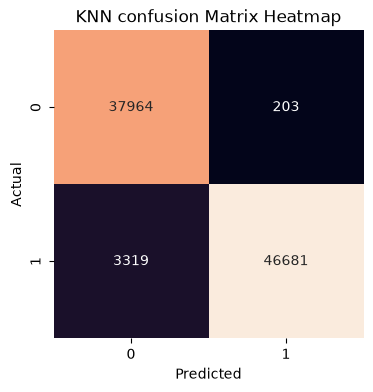

In [14]:

print("Testing Scores::")
report_test = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
print(f"Classification_report: {classification_report(y_test , y_pred)}")
cm = confusion_matrix(y_test , y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm , annot=True ,fmt="d" , cbar=False)
plt.title("Evaluationn on Test Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN confusion Matrix Heatmap")

plt.savefig('../benchmark_outputs/KNN_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [15]:
import joblib

# 1. Save your trained pipeline to a file
joblib.dump(knn_pipe, '../models/KNN_model_pipeline.joblib')


['../models/KNN_model_pipeline.joblib']